# Carbon-aware HPC scheduling - results across the whole project



The question every phase serves is one formula:

$$C(\text{job}, t) = \int_{t}^{t+d} P(\tau)\, \mathrm{CI}(\tau)\, \mathrm{d}\tau$$

Energy is fixed by the job. **Only $t$ is a decision**, and it only matters
because $\mathrm{CI}$ moves. So the whole project is: measure how much
$\mathrm{CI}$ moves, predict it, predict the jobs, and then move $t$.

| Phase | Package | What it produces | Where it is read below |
| ----- | ------- | ---------------- | ---------------------- |
| Carbon model | `carbon_accounting` | `energy_kWh`, `gCO2e` per job | §1 |
| Grid signal | `carbon_intensity` | the IT-NO observed series | §2 |
| Job models | `job_prediction` | duration and power at submission | §3 |
| CI forecasting | `carbon_intensity.boosted` | 24 h trajectories, issued hourly | §4 |
| Simulator + baselines | `hpc_sim` | replay, FCFS, EASY, power cap | §5 |
| Carbon-aware policies | `hpc_sim.carbon_aware` | the 65-configuration matrix | §6 |
| Delay-budget frontier | `scripts/carbon_tradeoff.py` | carbon vs QoS exchange rate | §7 |
| Information ablation | `experiments.ablation` | which prediction costs more | §8 |

Two companion notebooks go deeper on the raw inputs and are not repeated here:
[`dataset_inspection.ipynb`](dataset_inspection.ipynb) for the PM100 trace and
[`carbon_intensity_inspection.ipynb`](carbon_intensity_inspection.ipynb) for
the grid series.

In [1]:
from datetime import timedelta
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

from carbon_intensity.protocol import TemporalProtocol
from carbon_intensity.series import TimeSeriesCarbonIntensityProvider
from hpc_sim.carbon_aware import CarbonSignal

PROJECT_ROOT = Path("../").resolve()
DATA = PROJECT_ROOT / "data"
UNIT = "gCO2eq/kWh"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

INK, TEAL, RUST, SAND, GREY = "#0B3C49", "#177E89", "#E4572E", "#F2C57C", "#9AA5AB"
# One colour per carbon signal, reused in every figure that compares signals.
SIGNAL_COLORS = {
    "carbon-blind": "#C7CDD1", "oracle": INK, "persistence": "#B8C4C9",
    "seasonal_daily": SAND, "seasonal_weekly": "#D9A05B", "ridge_direct": TEAL,
    "ridge_refit_once": "#3C9EA8", "ridge_refit_14d": "#66B2B8", "boosted_ridge": RUST,
}
POLICY_COLORS = {"none": GREY, "fixed": TEAL, "duration-scaled": RUST}


def effective_ci(emissions_tco2e, energy_mwh):
    """Emissions per unit of energy actually delivered, in gCO2eq/kWh.

    Energy is invariant to the schedule, so this is the one number that makes
    every scheduler in this project directly comparable: it is the mean grid
    intensity the schedule ended up buying its electricity at.
    """
    return emissions_tco2e * 1e6 / (energy_mwh * 1e3)


print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/alberto/Desktop/Repositories/Carbon-aware HPC


## 1. The carbon model, and the one number that compares everything

`carbon_accounting` integrates the measured 20-second power profile of each job
against the observed grid signal. Two consequences decide how the rest of the
notebook is read:

- **Energy is invariant to the schedule.** Moving a job changes neither its
  duration nor its power draw, so every scheduler below consumes the same MWh
  to six decimals. An "energy-aware" policy has nothing to optimise here; it
  can only move *when* the power is drawn, which is why the energy baseline in
  §5 caps power rather than energy.
- **Therefore emissions divided by energy is a pure schedule score.** It is the
  mean grid intensity the schedule bought its electricity at, in the same
  gCO2eq/kWh as the signal itself. Every table below carries it as
  `effective CI`, and its whole range across 65 configurations is under
  10 gCO2eq/kWh - which is the project's headline result stated in one unit.

In [2]:
provider = TimeSeriesCarbonIntensityProvider.load(DATA / "carbon_intensity" / "actual" / "actual.json")
protocol = TemporalProtocol.load(DATA / "carbon_intensity" / "actual" / "protocol.json")
ci = pd.Series(
    [sample.intensity_gco2e_per_kwh for sample in provider.samples],
    index=pd.DatetimeIndex([sample.timestamp for sample in provider.samples], name="timestamp"),
    name="intensity",
)

matrix = pd.read_csv(DATA / "simulations" / "latest_results_matrix.csv")
matrix["effective_ci"] = effective_ci(matrix.total_emissions_tco2e, matrix.total_energy_mwh)
matrix["signal"] = np.where(
    matrix.carbon_information.eq("none"), "carbon-blind",
    np.where(matrix.carbon_information.eq("actual"), "oracle", matrix.forecast_model),
)

WORKLOAD_WINDOW = (pd.Timestamp("2020-05-06T07:00Z"), pd.Timestamp("2020-10-13T05:00Z"))
COHORT_WINDOW = (pd.Timestamp("2020-10-05T14:00Z"), pd.Timestamp("2020-10-13T05:00Z"))

pd.Series({
    "CI buckets cached": f"{len(ci):,}",
    "CI span": f"{ci.index[0]:%Y-%m-%d} to {ci.index[-1]:%Y-%m-%d}",
    "workload window": f"{WORKLOAD_WINDOW[0]:%Y-%m-%d} to {WORKLOAD_WINDOW[1]:%Y-%m-%d} (157,062 jobs)",
    "scheduling cohort": f"{COHORT_WINDOW[0]:%Y-%m-%d} to {COHORT_WINDOW[1]:%Y-%m-%d} ({matrix.jobs.iloc[0]:,} jobs)",
    "energy, every configuration (MWh)": f"{matrix.total_energy_mwh.nunique()} distinct value: {matrix.total_energy_mwh.iloc[0]:,.5f}",
    "effective CI, min - max": f"{matrix.effective_ci.min():,.2f} - {matrix.effective_ci.max():,.2f} {UNIT}",
    "configurations in the matrix": len(matrix),
}, name="").to_frame()

,
CI buckets cached,"169,536"
CI span,2016-01-01 to 2020-10-31
workload window,"2020-05-06 to 2020-10-13 (157,062 jobs)"
scheduling cohort,"2020-10-05 to 2020-10-13 (23,560 jobs)"
"energy, every configuration (MWh)",1 distinct value: 67.52421
"effective CI, min - max",249.81 - 259.61 gCO2eq/kWh
configurations in the matrix,65


Two evaluation windows are nested inside each other and are **not**
interchangeable, which matters every time a number is compared below:

- the **workload window** (May-October 2020, 157,062 jobs) is the whole PM100
  trace and the carbon-forecasting test partition;
- the **scheduling cohort** (7.6 days in October, 23,560 jobs) is the held-out
  test partition of the *job* models, and is what the 65-configuration matrix
  and the ablation run on.

A saving measured on one is not comparable with a saving measured on the other:
they meet different stretches of the grid signal, a different job mix and a
different amount of contention. §4 measures how much of that difference the
forecast is responsible for, and §6 shows what it does to the results.

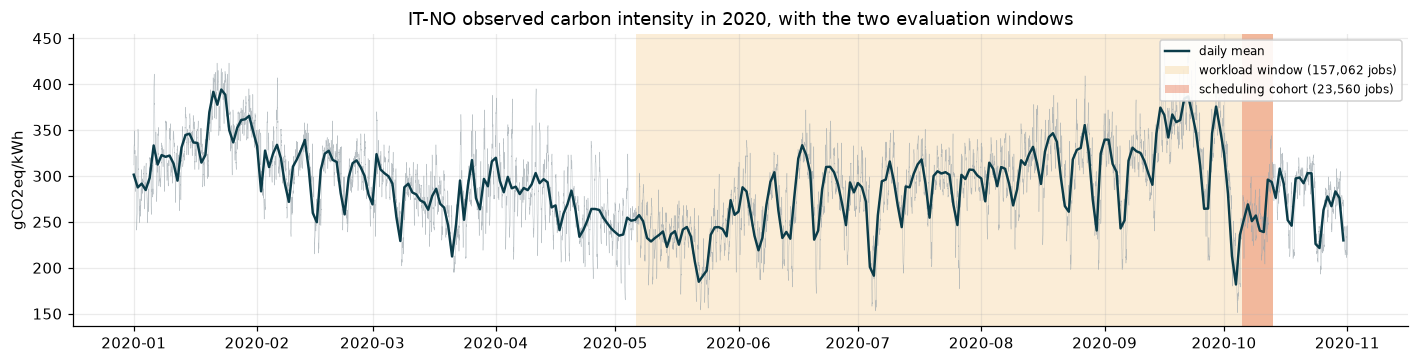

In [3]:
fig, ax = plt.subplots(figsize=(13, 3.4))
window = ci.loc[(ci.index >= pd.Timestamp("2020-01-01T00:00Z"))]
ax.plot(window.index, window.values, lw=0.3, color=GREY, alpha=0.7)
ax.plot(window.resample("D").mean(), lw=1.6, color=INK, label="daily mean")
ax.axvspan(*WORKLOAD_WINDOW, color=SAND, alpha=0.30, lw=0, label="workload window (157,062 jobs)")
ax.axvspan(*COHORT_WINDOW, color=RUST, alpha=0.35, lw=0, label="scheduling cohort (23,560 jobs)")
ax.set(ylabel=UNIT, title="IT-NO observed carbon intensity in 2020, with the two evaluation windows")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()

The cohort sits at the point where the seasonal wave has already turned back
upwards. Both windows are cleaner than the 2016-2019 training years, so every
model in the project is extrapolating downwards in level.

## 2. How much room is there? The ceiling the signal sets

Before any scheduler, the honest first question is how much a *perfect* policy
could save, because that bounds everything that follows.

Two bounds, and the distance between them is the interesting part:

1. **Bucket bound.** If every instant of work could be moved to the cheapest
   quarter-hour within a budget of `b` hours, what would the mean intensity be?
2. **Contention-free bound.** The same, but honest about the jobs: each job
   must run for *its own duration* starting at one of the candidate instants,
   so it averages the signal over that whole window. No queue, no node limit,
   no interaction between jobs - the greedy carbon rule with an infinite
   machine.

Bound 2 is computed with `hpc_sim.CarbonSignal`, the same integral the
scheduler itself scores candidates with.

In [4]:
signal = CarbonSignal(provider)
GRANULARITY = timedelta(minutes=15)
BUDGETS = (0, 1, 3, 6, 12, 24)

cohort_ids = pd.read_parquet(DATA / "job_predictions" / "test_predictions.parquet", columns=["job_id"])
cohort = (
    pd.read_parquet(DATA / "processed" / "pm100_clean.parquet", columns=["job_id", "release_time"])
    .merge(cohort_ids, on="job_id")
    .merge(
        pd.read_parquet(
            DATA / "job_predictions" / "scheduling_impact_jobs.parquet",
            columns=["job_id", "actual_duration_s", "actual_average_power_w"],
        ),
        on="job_id",
    )
)
cohort["energy_kwh"] = cohort.actual_average_power_w * cohort.actual_duration_s / 3.6e6

releases = cohort.release_time.dt.to_pydatetime()
durations = np.maximum(cohort.actual_duration_s.to_numpy(float), 1.0)
energy = cohort.energy_kwh.to_numpy()


def cheapest_reachable_intensity(budget_hours):
    """Mean intensity each job would see at the best start inside its budget."""
    best = np.empty(len(cohort))
    for index, (release, duration) in enumerate(zip(releases, durations)):
        span = timedelta(seconds=duration)
        lowest = signal.mean_intensity(release, release + span)
        # The candidate grid the policy itself uses: release, then every bucket
        # boundary up to the deadline.
        candidate = release - timedelta(
            minutes=release.minute % 15, seconds=release.second,
            microseconds=release.microsecond,
        ) + GRANULARITY
        deadline = release + timedelta(hours=budget_hours)
        while candidate <= deadline:
            lowest = min(lowest, signal.mean_intensity(candidate, candidate + span))
            candidate += GRANULARITY
        best[index] = lowest
    return best


cohort_ci = ci.loc[(ci.index >= COHORT_WINDOW[0]) & (ci.index < COHORT_WINDOW[1])]
bounds = []
for budget in BUDGETS:
    steps = int(budget * 4)
    bucket_bound = cohort_ci.rolling(steps + 1).min().shift(-steps).mean()
    reachable = cheapest_reachable_intensity(budget)
    bounds.append({
        "budget (h)": budget,
        "bucket bound": bucket_bound,
        "contention-free bound": float((reachable * energy).sum() / energy.sum()),
        "tCO2e": float((reachable * energy).sum() / 1e6),
    })
bounds = pd.DataFrame(bounds).set_index("budget (h)")
bounds["bucket saving"] = 1 - bounds["bucket bound"] / bounds["bucket bound"].iloc[0]
bounds["reachable saving"] = 1 - bounds["contention-free bound"] / bounds["contention-free bound"].iloc[0]
bounds

,bucket bound,contention-free bound,tCO2e,bucket saving,reachable saving
budget (h),,,,,
0,258.474,259.678,17.535,0.000,0.000
1,253.846,259.050,17.492,0.018,0.002
3,247.657,256.410,17.314,0.042,0.013
6,241.021,254.518,17.186,0.068,0.020
12,233.196,249.811,16.868,0.098,0.038
24,223.421,244.710,16.524,0.136,0.058


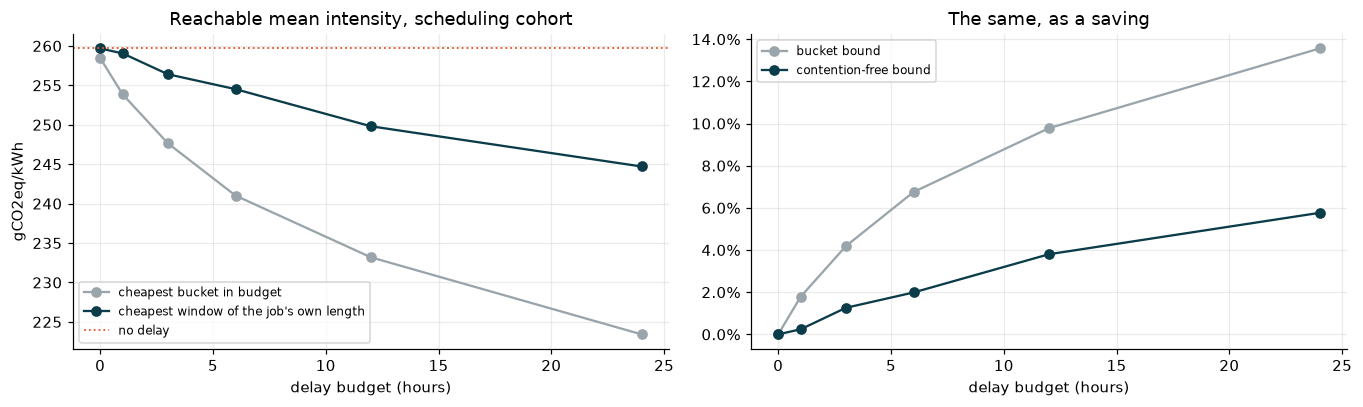

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
axes[0].plot(bounds.index, bounds["bucket bound"], "o-", color=GREY, label="cheapest bucket in budget")
axes[0].plot(bounds.index, bounds["contention-free bound"], "o-", color=INK, label="cheapest window of the job's own length")
axes[0].axhline(bounds["contention-free bound"].iloc[0], color=RUST, ls=":", lw=1.2, label="no delay")
axes[0].set(xlabel="delay budget (hours)", ylabel=UNIT, title="Reachable mean intensity, scheduling cohort")
axes[0].legend(fontsize=8)

axes[1].plot(bounds.index, bounds["bucket saving"], "o-", color=GREY, label="bucket bound")
axes[1].plot(bounds.index, bounds["reachable saving"], "o-", color=INK, label="contention-free bound")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set(xlabel="delay budget (hours)", title="The same, as a saving")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**The gap between the two curves is job duration, and it is most of the
headroom.** Chasing a single clean quarter-hour is worth about 6.8% at a
six-hour budget; running a real job across its whole duration from that instant
is worth only 2.0%. A job long enough to span the trough averages the trough
away, and jobs of at least an hour carry 93% of this cohort's energy (next
cell).

So before any queueing, contention or prediction error is introduced, a greedy
carbon policy on a six-hour budget has **about two percent** to play for on this
cohort. Everything in §6 and §7 is a share of that, not of the 6.8%.

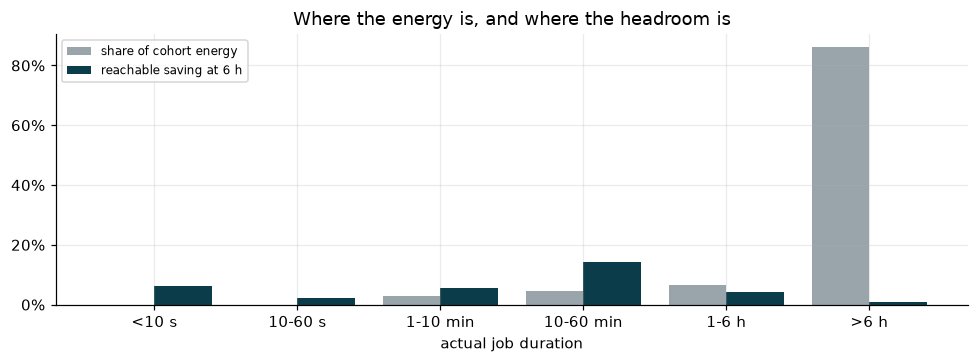

,jobs,share of energy,reachable saving at 6 h
band,,,
<10 s,16273,0.000,0.063
10-60 s,389,0.000,0.022
1-10 min,1749,0.029,0.055
10-60 min,2737,0.044,0.141
1-6 h,1578,0.065,0.043
>6 h,834,0.862,0.009


In [6]:
reachable_6h = cheapest_reachable_intensity(6)
baseline_6h = cheapest_reachable_intensity(0)
bands = pd.cut(
    cohort.actual_duration_s,
    [0, 10, 60, 600, 3600, 6 * 3600, np.inf], right=False,
    labels=["<10 s", "10-60 s", "1-10 min", "10-60 min", "1-6 h", ">6 h"],
)
by_band = pd.DataFrame({
    "band": bands, "energy_kwh": energy,
    "saving": 1 - reachable_6h / baseline_6h,
}).groupby("band", observed=True)
profile = pd.DataFrame({
    "jobs": by_band.size(),
    "share of energy": by_band.energy_kwh.sum() / energy.sum(),
    "reachable saving at 6 h": by_band.apply(
        lambda group: np.average(group["saving"], weights=group["energy_kwh"])
    ),
})

fig, ax = plt.subplots(figsize=(9, 3.4))
positions = np.arange(len(profile))
ax.bar(positions - 0.2, profile["share of energy"], 0.4, color=GREY, label="share of cohort energy")
ax.bar(positions + 0.2, profile["reachable saving at 6 h"], 0.4, color=INK, label="reachable saving at 6 h")
ax.set_xticks(positions, profile.index.astype(str))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(xlabel="actual job duration", title="Where the energy is, and where the headroom is")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
profile

This is the structural problem of carbon-aware HPC scheduling on this trace:
**the jobs that carry the energy are the jobs with the least to gain from being
moved.** Jobs over six hours hold 86% of the cohort's energy and can only reach
0.9%; jobs of 10-60 minutes can reach 14% but hold 4% of the energy. Weighted
together that is the 2.0% of the table above - a policy can only work in the
middle of the distribution, and the middle is thin.

## 3. Predicting the jobs: duration and average power at submission time

`job_prediction` fills the two seams the policies read - `scheduling_duration_seconds`
and `scheduling_average_power_watts` - from features available at submission. 
Two models are carried throughout: a ridge baseline and the selected `HistGradientBoosting`.

In [7]:
JOBS = DATA / "job_predictions"
model_paths = {"gradient boosting": JOBS, "ridge baseline": JOBS / "ridge_baseline"}
accuracy = pd.concat(
    {name: pd.read_csv(path / "test_metrics.csv").set_index("estimate") for name, path in model_paths.items()},
    names=["model"],
)
accuracy[[
    "count", "weighted_absolute_relative_error", "median_absolute_relative_error",
    "bias", "long_job_wape", "long_job_bias",
]].rename(columns={
    "weighted_absolute_relative_error": "WAPE", "median_absolute_relative_error": "median |rel err|",
    "long_job_wape": "WAPE, jobs >=1 h", "long_job_bias": "bias, jobs >=1 h",
})

count  WAPE  median |rel err|  \
model             estimate                                             
gradient boosting duration model       23560 0.429             0.312   
                  average-power model  23560 0.199             0.138   
                  energy model         23560 0.648             0.437   
                  composed energy      23560 0.552             0.351   
ridge baseline    duration model       23560 1.018            73.890   
                  average-power model  23560 0.214             0.173   
                  energy model         23560 1.003           107.263   
                  composed energy      23560 0.974            84.290   

                                            bias  WAPE, jobs >=1 h  \
model             estimate                                           
gradient boosting duration model        -568.060             0.385   
                  average-power model   -184.530             0.116   
                  energy model            -1.051             0.628   
                  composed energy         -1.028             0.522   
ridge baseline    duration model      -2,590.457             0.992   
                  average-power model   -214.833             0.195   
                  energy model            -2.813             0.998   
                  composed energy         -2.731             0.995   

                                       bias, jobs >=1 h  
model             estimate                               
gradient boosting duration model             -6,744.874  
                  average-power model          -144.231  
                  energy model                  -10.484  
                  composed energy               -10.417  
ridge baseline    duration model            -24,505.080  
                  average-power model          -382.790  
                  energy model                  -25.875  
                  composed energy               -25.810

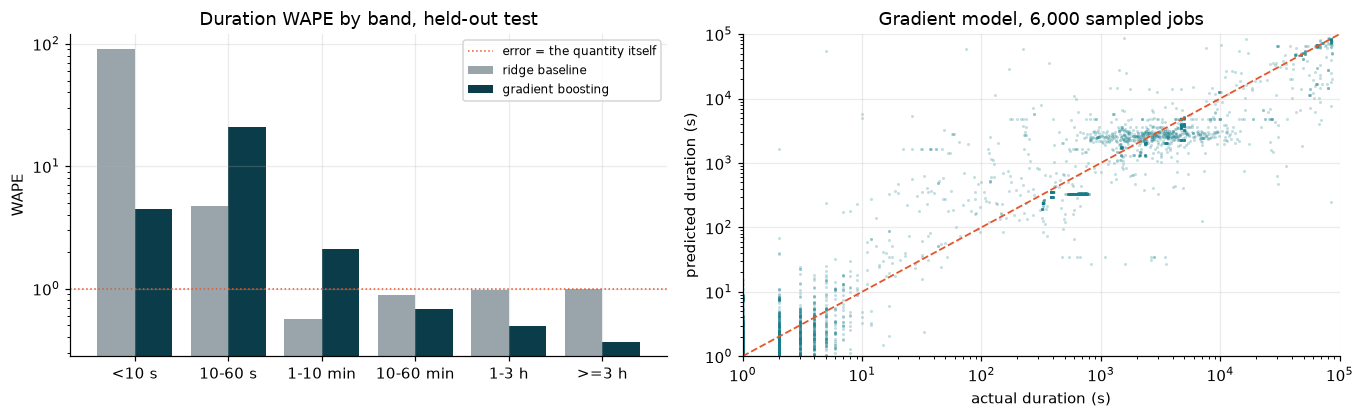

In [8]:
duration_bands = pd.concat(
    {name: pd.read_csv(path / "test_duration_bands.csv") for name, path in model_paths.items()},
    names=["model"],
).reset_index("model")
duration_bands = duration_bands[duration_bands.target.eq("duration_seconds")]
wape_by_band = duration_bands.pivot(index="band", columns="model", values="weighted_absolute_relative_error")
band_order = ["<10 s", "10-60 s", "1-10 min", "10-60 min", "1-3 h", ">=3 h"]
wape_by_band = wape_by_band.reindex(band_order)

impact = pd.read_parquet(JOBS / "scheduling_impact_jobs.parquet")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))
positions = np.arange(len(wape_by_band))
axes[0].bar(positions - 0.2, wape_by_band["ridge baseline"], 0.4, color=GREY, label="ridge baseline")
axes[0].bar(positions + 0.2, wape_by_band["gradient boosting"], 0.4, color=INK, label="gradient boosting")
axes[0].axhline(1.0, color=RUST, lw=1, ls=":", label="error = the quantity itself")
axes[0].set_xticks(positions, wape_by_band.index.astype(str))
axes[0].set_yscale("log")
axes[0].set(title="Duration WAPE by band, held-out test", ylabel="WAPE")
axes[0].legend(fontsize=8)

sample = impact.sample(6000, random_state=0)
axes[1].scatter(
    sample.actual_duration_s.clip(lower=1), sample.predicted_duration_s.clip(lower=1),
    s=4, alpha=0.25, color=TEAL, lw=0,
)
limits = (1, 1e5)
axes[1].plot(limits, limits, color=RUST, lw=1.2, ls="--")
axes[1].set(xscale="log", yscale="log", xlim=limits, ylim=limits,
            xlabel="actual duration (s)", ylabel="predicted duration (s)",
            title="Gradient model, 6,000 sampled jobs")
fig.tight_layout()
plt.show()

The gradient model is the one that made carbon-aware scheduling on predictions
worth running: 42.9% duration WAPE against the ridge's 101.7%, which is
worse than predicting a constant. But the scatter shows the residual problem
plainly - the cloud sits **below** the diagonal for long jobs. The model
under-predicts duration by 6,745 s on jobs of at least an hour, and §5 shows
that this single bias is enough to turn EASY backfilling back into FCFS.

## 4. Predicting the grid: 24hour carbon-intensity forecasts

Issued hourly, 96 quarter-hourly buckets each, scored on the whole
May-October test partition that the model selection never touched. Three naive
baselines, the incumbent ridge and its refit variants, and the selected
`boosted_ridge` (a direct per-bucket ridge plus a gradient-boosted residual per
lead band, trained on deviations from the last observation).

In [9]:
FORECASTS = DATA / "carbon_intensity" / "forecasts"


def forecast_table(stem, key):
    """Merge the ridge-era and boosted-era artifacts into one frame."""
    frames = [pd.read_csv(FORECASTS / f"test_{stem}.csv"), pd.read_csv(FORECASTS / f"boosted_test_{stem}.csv")]
    return pd.concat(frames).drop_duplicates(["model", *key])


MODEL_ORDER = ["persistence", "seasonal_daily", "seasonal_weekly", "ridge_direct",
               "ridge_refit_once", "ridge_refit_14d", "boosted_ridge"]
overall = forecast_table("metrics", []).set_index("model").reindex(MODEL_ORDER)
overall[["forecasts", "predicted_buckets", "mae_gco2e_per_kwh", "rmse_gco2e_per_kwh", "bias_gco2e_per_kwh"]]

,forecasts,predicted_buckets,mae_gco2e_per_kwh,rmse_gco2e_per_kwh,bias_gco2e_per_kwh
model,,,,,
persistence,3815,366240,28.312,36.523,-0.157
seasonal_daily,3815,366240,26.400,34.926,-0.145
seasonal_weekly,3815,366240,30.394,40.454,-0.496
ridge_direct,3815,366240,18.208,23.988,2.342
ridge_refit_once,3815,366240,18.219,24.012,2.234
ridge_refit_14d,3815,366240,18.210,24.003,2.152
boosted_ridge,3815,366240,17.009,22.592,2.277


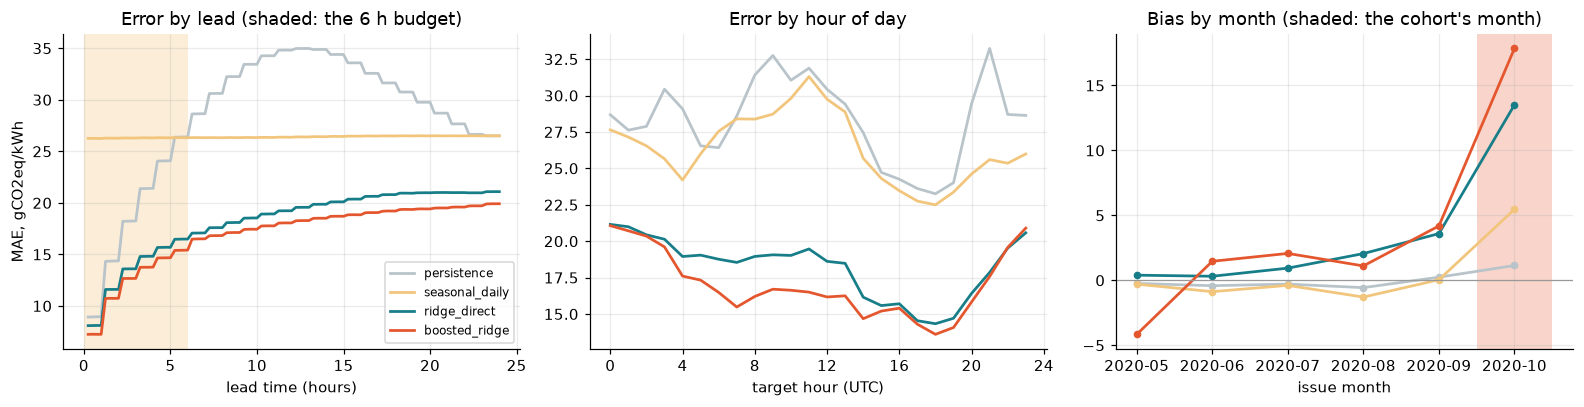

In [10]:
horizon = forecast_table("horizon_metrics", ["lead_hours"])
hour = forecast_table("hour_metrics", ["target_hour_utc"])
monthly = forecast_table("monthly_metrics", ["issue_month"])
shown = ["persistence", "seasonal_daily", "ridge_direct", "boosted_ridge"]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.8))
for model in shown:
    rows = horizon[horizon.model.eq(model)].sort_values("lead_hours")
    axes[0].plot(rows.lead_hours, rows.mae_gco2e_per_kwh, color=SIGNAL_COLORS[model], lw=1.8, label=model)
    rows = hour[hour.model.eq(model)].sort_values("target_hour_utc")
    axes[1].plot(rows.target_hour_utc, rows.mae_gco2e_per_kwh, color=SIGNAL_COLORS[model], lw=1.8)
    rows = monthly[monthly.model.eq(model)].sort_values("issue_month")
    axes[2].plot(rows.issue_month, rows.bias_gco2e_per_kwh, "o-", ms=4, color=SIGNAL_COLORS[model], lw=1.8)
axes[0].axvspan(0, 6, color=SAND, alpha=0.3, lw=0)
axes[0].set(xlabel="lead time (hours)", ylabel=f"MAE, {UNIT}", title="Error by lead (shaded: the 6 h budget)")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="target hour (UTC)", title="Error by hour of day")
axes[1].set_xticks(range(0, 25, 4))
axes[2].axhline(0, color="#999", lw=0.8)
axes[2].axvspan(4.5, 5.5, color=RUST, alpha=0.25, lw=0)
axes[2].set(xlabel="issue month", title="Bias by month (shaded: the cohort's month)")
fig.tight_layout()
plt.show()

Three readings, in order of how much they matter to the scheduler:

- **Inside a six-hour budget the forecast is good.** The boosted model runs
  from 7.2 gCO2eq/kWh at +15 min to 15.4 at +6 h, and beats every baseline at
  every one of the 96 leads. Cumulative over 0-6 h it scores 12.4 MAE against
  the 24-hour figure of 17.0, so the budget the schedulers actually use sits in
  the accurate part of the trajectory. Among the baselines, persistence is the
  better naive guess out to 5.25 h, where the seasonal ones - essentially flat
  in lead at ~26 - overtake it.
- **The error is worst exactly where the dirt is.** Every model peaks
  overnight, 22:00-03:00 UTC (boosted: 19.6-21.1), and is at its best in the
  late afternoon (13.6 at 18:00). That overnight plateau is the dirtiest part of the
  day and therefore the interval a carbon-aware policy most wants to avoid - it
  is least sure about the hours its decision hinges on.
- **And October is the worst month, over 24 hours.** Bias is near zero from May
  to August and then climbs sharply: +13.5 (ridge) and +17.9 (boosted)
  gCO2eq/kWh in October, the month the scheduling cohort lives in. The forecast
  believes October is dirtier than it is - but see the next cell before
  carrying that into the scheduler.

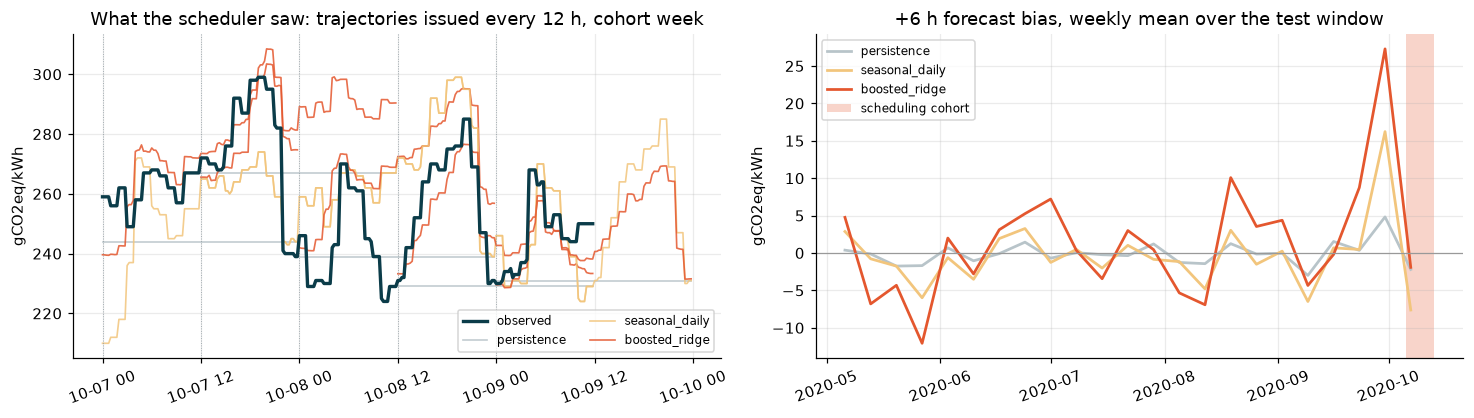

In [11]:
def load_archive(name):
    """Issue time -> (trajectory start, values) for one snapshot archive."""
    raw = json.loads((DATA / "carbon_intensity" / "snapshots" / f"test_{name}.json").read_text())
    return {
        pd.Timestamp(snapshot["issue_time"]):
            (pd.Timestamp(snapshot["start"]), np.asarray(snapshot["values_gco2e_per_kwh"], float))
        for snapshot in raw["snapshots"]
    }


archives = {name: load_archive(name) for name in ("persistence", "seasonal_daily", "boosted_ridge")}

day = (pd.Timestamp("2020-10-07T00:00Z"), pd.Timestamp("2020-10-09T00:00Z"))
observed = ci.loc[(ci.index >= day[0]) & (ci.index < day[1] + pd.Timedelta(hours=12))]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.9))
axes[0].plot(observed.index, observed.values, color=INK, lw=2.2, label="observed", zorder=5)
for offset, issue in enumerate(pd.date_range(day[0], day[1], freq="12h", tz="UTC")):
    for name, archive in archives.items():
        start, values = archive[issue]
        stamps = start + pd.to_timedelta(np.arange(len(values)) * 15, unit="m")
        axes[0].plot(stamps, values, color=SIGNAL_COLORS[name], lw=1.1, alpha=0.85,
                     label=name if offset == 0 else None)
    axes[0].axvline(issue, color=GREY, lw=0.6, ls=":")
axes[0].set(ylabel=UNIT, title="What the scheduler saw: trajectories issued every 12 h, cohort week")
axes[0].legend(fontsize=8, ncol=2)
axes[0].tick_params(axis="x", labelrotation=20)

lead_index = 24  # +6 hours on the 15-minute grid
errors = {}
for name, archive in archives.items():
    rows = {}
    for issue, (start, values) in archive.items():
        target = start + pd.Timedelta(minutes=15 * lead_index)
        if lead_index < len(values) and target in ci.index:
            rows[issue] = values[lead_index] - ci.loc[target]
    errors[name] = pd.Series(rows)
errors = pd.DataFrame(errors)
weekly_bias = errors.resample("7D").mean()
for name in errors:
    axes[1].plot(weekly_bias.index, weekly_bias[name], color=SIGNAL_COLORS[name], lw=1.8, label=name)
axes[1].axhline(0, color="#999", lw=0.8)
axes[1].axvspan(*COHORT_WINDOW, color=RUST, alpha=0.25, lw=0, label="scheduling cohort")
axes[1].set(ylabel=UNIT, title="+6 h forecast bias, weekly mean over the test window")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", labelrotation=20)
fig.tight_layout()
plt.show()

The monthly panel is a 0-24 h figure, though, and the schedulers only ever read
the first six hours of a trajectory. Scored on the window they actually use,
over the cohort week against the whole test period:

In [12]:
BUDGET_BUCKETS = 25  # release bucket plus six hours on the 15-minute grid
observed_values = ci.to_numpy()
observed_start = ci.index[0]


def budget_window_error(archive):
    """Signed error over the first six hours of every issued trajectory."""
    issues, errors = [], []
    for issue, (start, values) in archive.items():
        offset = int((start - observed_start).total_seconds() // 900)
        for lead in range(min(BUDGET_BUCKETS, len(values))):
            position = offset + lead
            if 0 <= position < len(observed_values):
                issues.append(issue)
                errors.append(values[lead] - observed_values[position])
    return pd.Series(errors, index=pd.DatetimeIndex(issues))


archives["ridge_direct"] = load_archive("ridge_direct")
budget_error = []
for name, archive in archives.items():
    error = budget_window_error(archive)
    cohort_error = error.loc[(error.index >= COHORT_WINDOW[0]) & (error.index < COHORT_WINDOW[1])]
    budget_error.append({
        "archive": name,
        "test window MAE": error.abs().mean(), "test window bias": error.mean(),
        "cohort week MAE": cohort_error.abs().mean(), "cohort week bias": cohort_error.mean(),
        "MAE penalty": cohort_error.abs().mean() / error.abs().mean() - 1,
    })
pd.DataFrame(budget_error).set_index("archive")

,test window MAE,test window bias,cohort week MAE,cohort week bias,MAE penalty
archive,,,,,
persistence,19.287,-0.040,18.071,-1.062,-0.063
seasonal_daily,26.445,-0.312,27.583,-11.402,0.043
boosted_ridge,12.586,0.903,13.452,1.044,0.069
ridge_direct,13.535,1.054,15.105,1.813,0.116


**Inside the six-hour budget the cohort week is only modestly harder**, not
catastrophically so: `boosted_ridge` scores 13.45 MAE there against 12.59 over
the whole test window (+7%), `ridge_direct` 15.10 against 13.53 (+12%), and
their bias stays near +1. The October blow-up in the monthly panel is real but
it lives in the far horizons, which no six-hour policy reads.

That matters for how §6 is read: when oracle recovery drops from 62% over the
whole workload window to 41% over the cohort (`boosted_ridge`; 64% and 41% for
`ridge_direct`), most of the drop is *not* forecast degradation. The two are different experiments - a different week of
grid signal, a different job mix, a different amount of contention - and the
right conclusion is that a recovery figure belongs to its window.

The left panel is the honest picture of what a carbon-aware policy actually
consumes: `persistence` is a flat line and can never prefer one start over
another, `seasonal_daily` has the right shape at the wrong level, and only the
boosted model tracks both. The right panel dates the autumn drift: the +6 h
bias is small and sign-changing for five months, then spikes to +27 gCO2eq/kWh
in the week ending as the cohort opens, before swinging back. The cohort sits
in the most volatile fortnight of the record rather than in a uniformly bad
one.

## 5. The simulator and the carbon-blind baselines

`hpc_sim` is a continuous-time discrete-event simulator over 880 nodes.
`TraceReplayScheduler` reproduces every recorded start time exactly, which is
the engine's ground-truth anchor. The three policies under study here are
carbon-blind by construction: FCFS, EASY backfilling, and EASY under an
aggregate power cap - the energy-aware baseline.

In [13]:
blind = matrix[matrix.carbon_information.eq("none")].copy()
blind["label"] = blind.scheduler + " (" + blind.job_model + " job info)"
blind.set_index("label")[[
    "effective_ci", "total_emissions_tco2e", "total_energy_mwh", "peak_power_mw",
    "waiting_mean_s", "waiting_p95_s", "bounded_slowdown_mean", "bounded_slowdown_p95", "utilisation",
]]

,effective_ci,total_emissions_tco2e,total_energy_mwh,peak_power_mw,waiting_mean_s,waiting_p95_s,bounded_slowdown_mean,bounded_slowdown_p95,utilisation
label,,,,,,,,,
trace-replay (actual job info),259.176,17.501,67.524,0.691,"3,265.150","17,544.000",8.557,24.500,0.475
fcfs (actual job info),258.802,17.475,67.524,0.844,458.262,"1,341.000",3.000,1.852,0.475
easy (actual job info),258.740,17.471,67.524,0.850,422.904,0.000,2.111,1.000,0.475
power-cap (actual job info),258.810,17.476,67.524,0.675,475.490,123.000,1.814,1.019,0.475
easy (gradient job info),258.802,17.475,67.524,0.844,458.262,"1,341.000",3.000,1.852,0.475
power-cap (gradient job info),258.765,17.473,67.524,0.794,565.101,"2,000.000",3.695,2.610,0.475
easy (ridge job info),258.802,17.475,67.524,0.844,458.262,"1,341.000",3.000,1.852,0.475
power-cap (ridge job info),258.802,17.475,67.524,0.844,458.262,"1,341.000",3.000,1.852,0.475


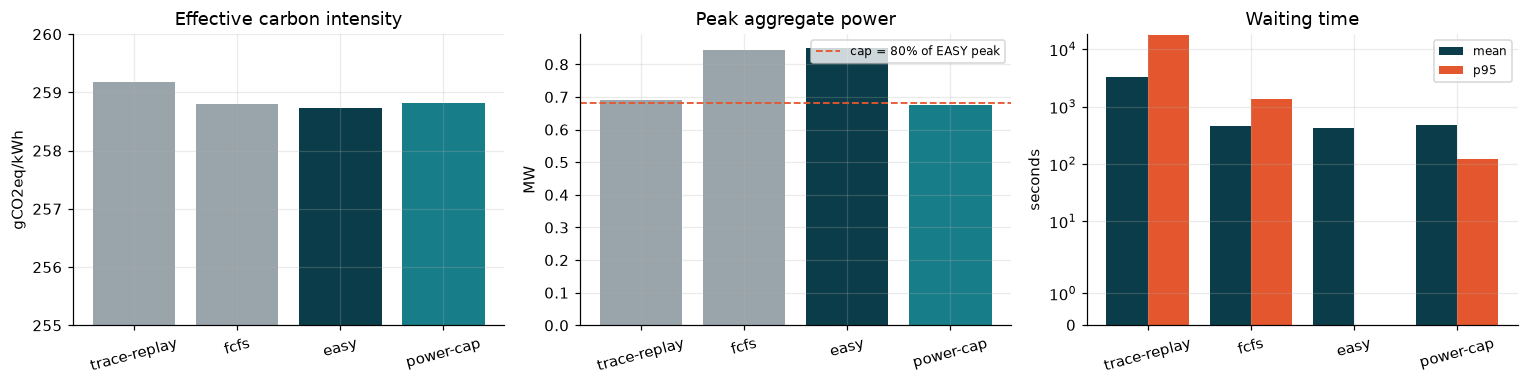

In [14]:
reference = matrix[matrix.scheduler.eq("easy") & matrix.job_model.eq("actual")].iloc[0]
actual_blind = blind[blind.job_model.eq("actual")]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
positions = np.arange(len(actual_blind))
labels = actual_blind.scheduler.to_list()
axes[0].bar(positions, actual_blind.effective_ci - 255, color=[GREY, GREY, INK, TEAL], bottom=255)
axes[0].set_xticks(positions, labels, rotation=15)
axes[0].set(ylim=(255, 260), ylabel=UNIT, title="Effective carbon intensity")
axes[1].bar(positions, actual_blind.peak_power_mw, color=[GREY, GREY, INK, TEAL])
axes[1].axhline(reference.peak_power_mw * 0.8, color=RUST, ls="--", lw=1.2, label="cap = 80% of EASY peak")
axes[1].set_xticks(positions, labels, rotation=15)
axes[1].set(ylabel="MW", title="Peak aggregate power")
axes[1].legend(fontsize=8)
axes[2].bar(positions - 0.2, actual_blind.waiting_mean_s, 0.4, color=INK, label="mean")
axes[2].bar(positions + 0.2, actual_blind.waiting_p95_s, 0.4, color=RUST, label="p95")
axes[2].set_xticks(positions, labels, rotation=15)
axes[2].set_yscale("symlog")
axes[2].set(ylabel="seconds", title="Waiting time")
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

This is the reference frame the rest of the notebook is measured against, and
it makes four points at once.

- **Carbon-blind means carbon-flat.** Replay, FCFS, EASY and the power cap all
  land within 0.44 gCO2eq/kWh of each other - 0.17% of the level. None of them
  is trying to move emissions, and the small differences are incidental overlap
  with the signal. That flatness is what makes any of them a fair reference.
- **The energy-aware baseline can only move the peak.** It cuts peak power from
  0.850 to 0.675 MW, exactly the budget it was given, at identical MWh and
  essentially identical emissions. In this model that is the only thing an
  energy-aware policy *can* do, and it is the sharpest statement of why
  carbon-aware and energy-aware are different objectives.
- **Predicted job inputs cost QoS before any carbon policy runs.** The
  `easy (gradient job info)` and `easy (ridge job info)` rows are not merely
  close to the `fcfs` row - they are identical to it, column for column. The
  duration bias of §3 projects every running long job as already finished, the
  EASY reservation lands at or before `now`, and the scheduler correctly falls
  back to strict FCFS on every pass that has a pivot. Backfilling stops working
  entirely, at a cost of 35 s of mean waiting and 0.9 of mean bounded slowdown.
- **The trace itself is the worst schedule on QoS.** Replay waits 3,265 s on
  average against EASY's 423 s: the real system was not running a work-conserving
  policy, so a comparison against the trace would flatter any simulated policy.
  EASY is the reference used everywhere below.

(EASY's p95 waiting time is exactly zero - at least 95% of jobs start the
instant they become eligible - which is why its bar is missing from the third
panel rather than merely small.)

## 6. Carbon-aware scheduling: the full parameter matrix

65 configurations on one cohort, one cluster and one delay budget. Three axes
vary, and nothing else:

| Axis | Values |
| ---- | ------ |
| **Job information** | actual (oracle), gradient model, ridge model |
| **Carbon information** | none, observed (oracle), 7 forecast archives |
| **Delay policy** | none, fixed 6 h, duration-scaled (budget = predicted runtime) |

Every run is scored ex post: measured power profiles against the observed
signal, whatever the policy planned on. `oracle_recovery` is the share of the
perfect-information saving a run keeps, and `emissions_saved_vs_easy` is
measured against EASY *within the same job-information arm*, so the three arms
each have their own zero.

In [15]:
delay_order = ["none", "fixed", "duration-scaled"]
signal_order = ["carbon-blind", "oracle", "persistence", "seasonal_daily", "seasonal_weekly",
                "ridge_direct", "ridge_refit_once", "ridge_refit_14d", "boosted_ridge"]
job_order = ["actual", "gradient", "ridge"]

# Every forecast run is capped at the archive's reach, and so is the oracle it
# is measured against. Mixing the uncapped runs (`carbon-aware`,
# `carbon-scaled-delay`) or the power-capped ones into the same cell would
# average two different policies, so the heatmap keeps the reach-bounded
# variants only; the uncapped oracle appears on its own in §9.
COMPARABLE = {
    "easy", "carbon-aware-bounded", "carbon-scaled-delay-bounded",
    "carbon-aware-forecast-bounded", "carbon-forecast-scaled-delay-bounded",
}

view = matrix.copy()
view["delay_policy"] = pd.Categorical(view.delay_policy, delay_order, ordered=True)
view["signal"] = pd.Categorical(view.signal, signal_order, ordered=True)
view["job_model"] = pd.Categorical(view.job_model, job_order, ordered=True)
view = view.sort_values(["job_model", "delay_policy", "signal"])

view.set_index(["job_model", "delay_policy", "signal", "scheduler"])[[
    "effective_ci", "total_emissions_tco2e", "emissions_saved_vs_easy", "oracle_recovery",
    "waiting_mean_s", "waiting_p95_s", "bounded_slowdown_mean", "bounded_slowdown_p95",
    "peak_power_mw", "utilisation",
]]

effective_ci  \
job_model delay_policy    signal           scheduler                                            
actual    none            carbon-blind     trace-replay                               259.176   
                                           fcfs                                       258.802   
                                           easy                                       258.740   
                                           power-cap                                  258.810   
          fixed           oracle           carbon-aware                               255.319   
...                                                                                       ...   
ridge     duration-scaled seasonal_weekly  carbon-forecast-scaled-delay-bounded       258.804   
                          ridge_direct     carbon-forecast-scaled-delay-bounded       258.791   
                          ridge_refit_once carbon-forecast-scaled-delay-bounded       258.800   
                          ridge_refit_14d  carbon-forecast-scaled-delay-bounded       258.800   
                          boosted_ridge    carbon-forecast-scaled-delay-bounded       258.792   

                                                                                 total_emissions_tco2e  \
job_model delay_policy    signal           scheduler                                                     
actual    none            carbon-blind     trace-replay                                         17.501   
                                           fcfs                                                 17.475   
                                           easy                                                 17.471   
                                           power-cap                                            17.476   
          fixed           oracle           carbon-aware                                         17.240   
...                                                                                                ...   
ridge     duration-scaled seasonal_weekly  carbon-forecast-scaled-delay-bounded                 17.476   
                          ridge_direct     carbon-forecast-scaled-delay-bounded                 17.475   
                          ridge_refit_once carbon-forecast-scaled-delay-bounded                 17.475   
                          ridge_refit_14d  carbon-forecast-scaled-delay-bounded                 17.475   
                          boosted_ridge    carbon-forecast-scaled-delay-bounded                 17.475   

                                                                                 emissions_saved_vs_easy  \
job_model delay_policy    signal           scheduler                                                       
actual    none            carbon-blind     trace-replay                                           -0.002   
                                           fcfs                                                   -0.000   
                                           easy                                                    0.000   
                                           power-cap                                              -0.000   
          fixed           oracle           carbon-aware                                            0.013   
...                                                                                                  ...   
ridge     duration-scaled seasonal_weekly  carbon-forecast-scaled-delay-bounded                   -0.000   
                          ridge_direct     carbon-forecast-scaled-delay-bounded                    0.000   
                          ridge_refit_once carbon-forecast-scaled-delay-bounded                    0.000   
                          ridge_refit_14d  carbon-forecast-scaled-delay-bounded                    0.000   
                          boosted_ridge    carbon-forecast-scaled-delay-bounded                    0.000   

                                   

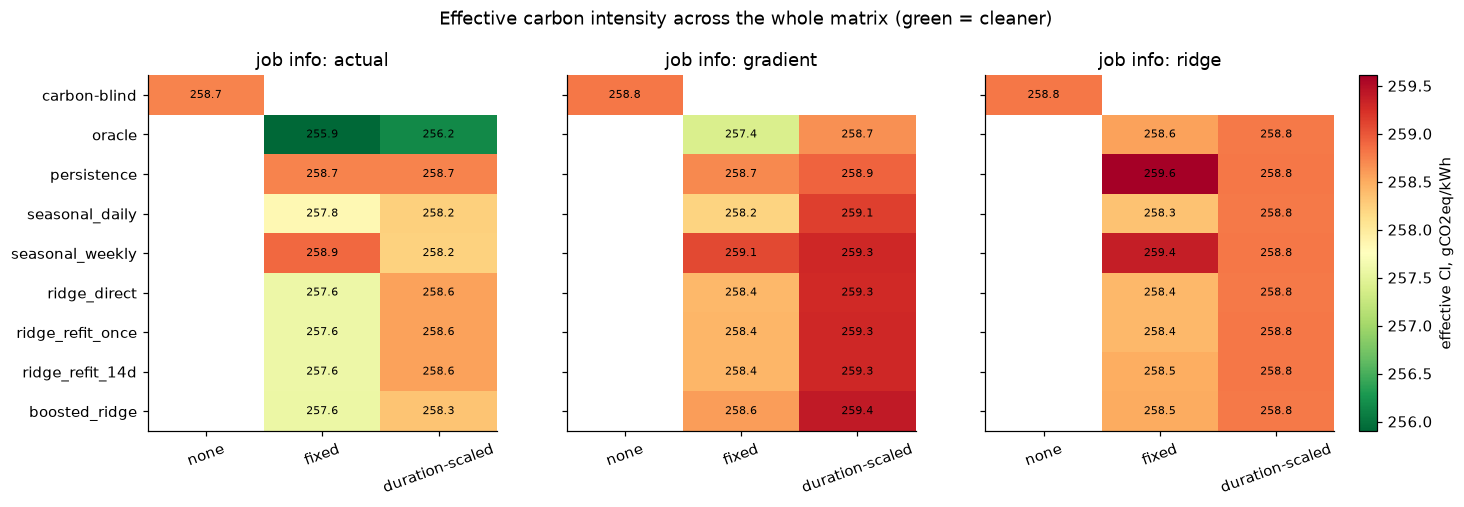

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharey=True)
comparable = matrix[matrix.scheduler.isin(COMPARABLE)]
vmin, vmax = comparable.effective_ci.min(), comparable.effective_ci.max()
for ax, job_model in zip(axes, job_order):
    grid = (
        view[view.job_model.eq(job_model) & view.scheduler.isin(COMPARABLE)]
        .pivot_table(index="signal", columns="delay_policy", values="effective_ci", observed=False)
        .reindex(index=signal_order, columns=delay_order)
    )
    mesh = ax.imshow(grid.values, cmap="RdYlGn_r", vmin=vmin, vmax=vmax, aspect="auto")
    for row in range(grid.shape[0]):
        for column in range(grid.shape[1]):
            value = grid.values[row, column]
            if np.isfinite(value):
                ax.text(column, row, f"{value:.1f}", ha="center", va="center", fontsize=7.5)
    ax.set_xticks(range(len(delay_order)), delay_order, rotation=20)
    ax.set_yticks(range(len(signal_order)), signal_order)
    ax.grid(False)
    ax.set_title(f"job info: {job_model}")
fig.colorbar(mesh, ax=axes, label=f"effective CI, {UNIT}", pad=0.02, fraction=0.02)
fig.suptitle("Effective carbon intensity across the whole matrix (green = cleaner)", y=1.02)
plt.show()

Every cell is one run, held to the same reach, so the panels are directly
comparable; they span **255.9 to 259.6 gCO2eq/kWh**, a range of 1.4%. Reading
them:

- **Down a column**: the carbon signal matters, and it matters in the right
  order - the observed series beats every forecast, and the learned forecasts
  beat the seasonal ones. `persistence` is the degenerate case: its trajectory
  is a single repeated value, so it can never prefer one start over another.
  With actual job inputs it reproduces EASY exactly; with predicted ones it
  does not, and the next cell shows why.
- **Across a row**: at equal reach the fixed six-hour budget beats the
  duration-scaled one almost everywhere. Released from the reach cap, though,
  the duration-scaled oracle is the cleanest run in the whole file at
  **249.8 gCO2eq/kWh - a 3.45% saving**, against 1.32% for the uncapped
  fixed-budget oracle. It gives long jobs long budgets, which is where §2 said
  the energy is; it is excluded from the panels only because no forecast
  archive reaches far enough to be compared with it.
- **Between panels**: job information dominates everything else. With the ridge
  job model the entire matrix collapses to a 1 gCO2eq/kWh band: predictions that
  bad make the carbon decision meaningless whatever the grid signal is.

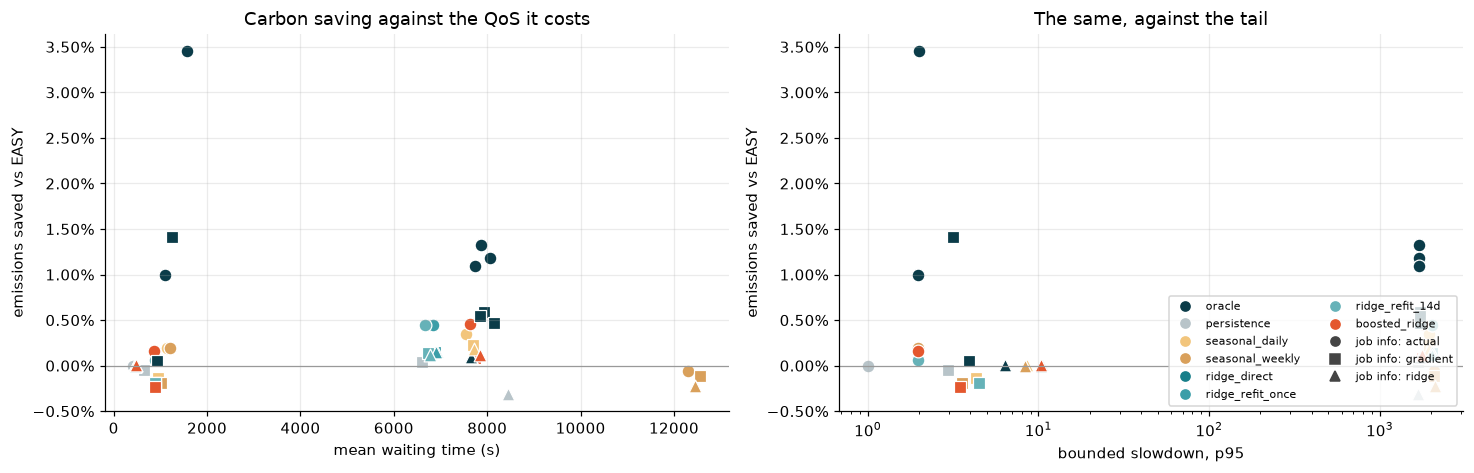

In [17]:
carbon = view[view.carbon_information.ne("none")]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
markers = {"actual": "o", "gradient": "s", "ridge": "^"}
for job_model, group in carbon.groupby("job_model", observed=True):
    for _, row in group.iterrows():
        axes[0].scatter(
            row.waiting_mean_s, row.emissions_saved_vs_easy,
            marker=markers[job_model], s=70, lw=0.8, edgecolor="white",
            color=SIGNAL_COLORS[row.signal],
        )
        axes[1].scatter(
            row.bounded_slowdown_p95, row.emissions_saved_vs_easy,
            marker=markers[job_model], s=70, lw=0.8, edgecolor="white",
            color=SIGNAL_COLORS[row.signal],
        )
for ax, xlabel, scale in ((axes[0], "mean waiting time (s)", "linear"),
                          (axes[1], "bounded slowdown, p95", "log")):
    ax.axhline(0, color="#999", lw=0.8)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set(xlabel=xlabel, ylabel="emissions saved vs EASY", xscale=scale)
axes[0].set_title("Carbon saving against the QoS it costs")
axes[1].set_title("The same, against the tail")

handles = [plt.Line2D([], [], marker="o", ls="", color=SIGNAL_COLORS[s], label=s) for s in signal_order[1:]]
handles += [plt.Line2D([], [], marker=m, ls="", color="#444", label=f"job info: {j}") for j, m in markers.items()]
axes[1].legend(handles=handles, fontsize=7.5, ncol=2, loc="lower right")
fig.tight_layout()
plt.show()

There is no frontier here, only a cloud, and that is the finding. Points that
cost 7,000-12,000 s of mean waiting save between -0.2% and +1.3%; the two
points that save the most per second of waiting are the duration-scaled oracle
runs at the far left. Nothing in the upper-left quadrant - a large saving at
small delay - exists on this cohort.

The right panel is the one to take seriously. Fixed-budget policies push p95
bounded slowdown past 1,700, meaning the worst-served 5% of jobs wait roughly
three orders of magnitude longer than they run. Duration-scaled budgets keep
p95 near 2-10 while giving up most of the saving. **The delay policy, not the
signal, decides whether a carbon-aware scheduler is deployable.**

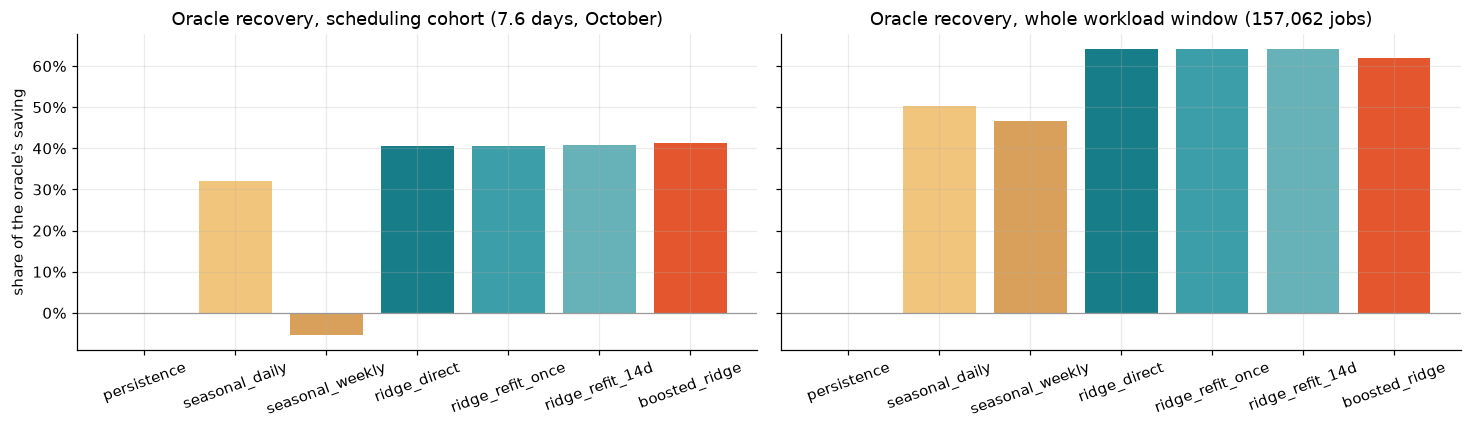

,"cohort, fixed 6 h","cohort, duration-scaled",whole workload window
signal,,,
persistence,0.000,0.000,0.000
seasonal_daily,0.320,0.193,0.504
seasonal_weekly,-0.054,0.199,0.467
ridge_direct,0.407,0.072,0.642
ridge_refit_once,0.407,0.068,0.642
ridge_refit_14d,0.408,0.068,0.643
boosted_ridge,0.413,0.159,0.620


In [18]:
forecast_rows = view[view.carbon_information.eq("forecast")]
recovery = forecast_rows.pivot_table(
    index="signal", columns=["job_model", "delay_policy"], values="oracle_recovery", observed=True
).reindex(signal_order[2:])

full_trace = pd.read_csv(FORECASTS / "test_scheduling_impact.csv")
full_trace = full_trace[full_trace.configuration.str.startswith("carbon_forecast_")]
full_trace["signal"] = full_trace.configuration.str.removeprefix("carbon_forecast_")
full_trace = full_trace.set_index("signal").reindex(signal_order[2:])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0), sharey=True)
positions = np.arange(len(recovery))
cohort_fixed = recovery[("actual", "fixed")]
axes[0].bar(positions, cohort_fixed, color=[SIGNAL_COLORS[s] for s in recovery.index])
axes[0].set(title="Oracle recovery, scheduling cohort (7.6 days, October)", ylabel="share of the oracle's saving")
axes[1].bar(positions, full_trace.oracle_recovery, color=[SIGNAL_COLORS[s] for s in full_trace.index])
axes[1].set(title="Oracle recovery, whole workload window (157,062 jobs)")
for ax in axes:
    ax.axhline(0, color="#999", lw=0.8)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xticks(positions, recovery.index.astype(str), rotation=20)
fig.tight_layout()
plt.show()
pd.DataFrame({
    "cohort, fixed 6 h": cohort_fixed,
    "cohort, duration-scaled": recovery[("actual", "duration-scaled")],
    "whole workload window": full_trace.oracle_recovery,
})

The same forecasts, the same policy, the same budget - and the recovery roughly
halves when the evaluation moves from the whole workload window to the October
cohort: `ridge_direct` keeps 64.2% over five months and 40.7% over the cohort
week. §4 measured the forecast itself as only 12% worse inside the six-hour
budget over that week, so most of this gap is *not* forecast quality: it is a
different week of signal, a different job mix and a different amount of
contention. Which is the strongest argument in the notebook for quoting a
recovery together with its window rather than on its own.

`boosted_ridge` is now in the right panel, and it is the one row that does not
behave: it keeps **61.98%** over the full workload window against
`ridge_direct`'s **64.21%**, despite scoring 6.6% better on 24 h MAE. Over the
cohort it is marginally ahead instead (41.29% against 40.66%). Every other row
of this comparison reproduced to the last decimal when it was re-run, so this
is the forecast and not the harness: **a lower forecast MAE does not
mechanically buy better scheduling decisions.** The booster earns its MAE
mostly at the near leads, and the policy's choice between candidate starts
depends on the *shape* of the trajectory across the whole six-hour budget, not
on its average accuracy.

### An artefact worth knowing about before reading the `persistence` rows

`persistence` repeats one observed value across all 96 buckets, so every
candidate start has *identical* predicted cost and the policy's documented
tie-break - "ties go to the earliest candidate" - should reproduce EASY. It
does, with actual job inputs. With predicted ones it holds 73% of the jobs.

The cell below replays the decisions alone, with no simulation, and prices the
spread between the cheapest and the dearest candidate each held job was
choosing between.

In [19]:
from carbon_intensity.snapshots import ArchiveCarbonIntensityProvider, ForecastArchive
from hpc_sim.carbon_aware import CarbonAwareScheduler, candidate_start_times, carbon_cost_gco2e
from job_prediction import load_prediction_cohort


class _NoWakeups:
    #: The policy only needs somewhere to post its wakeups; nothing runs.
    def request_wakeup(self, when):
        pass


actual_jobs, predicted_jobs = load_prediction_cohort(
    DATA / "processed" / "pm100_clean.parquet",
    DATA / "job_predictions" / "test_predictions.parquet",
)

tie_break = []
for name in ("persistence", "seasonal_daily", "boosted_ridge"):
    archive = ForecastArchive.load(DATA / "carbon_intensity" / "snapshots" / f"test_{name}.json")
    archive_provider = ArchiveCarbonIntensityProvider(provider, archive)
    reach = (timedelta(hours=archive.metadata["horizon_hours"])
             - timedelta(minutes=archive.metadata["cadence_minutes"]))
    for label, jobs in (("actual", actual_jobs), ("gradient", predicted_jobs)):
        policy = CarbonAwareScheduler(
            archive_provider, forecast=True, max_delay=timedelta(hours=6), reach=reach
        )
        held, spreads = 0, []
        for job in jobs:
            policy.on_release(job, job.release_time, _NoWakeups())
            if policy.target_start_times[job.job_id] <= job.release_time:
                continue
            held += 1
            # No public accessor exposes the trajectory a decision read, so the
            # two private helpers below are used to re-score it in place.
            if len(spreads) < 400:  # the spread is stable long before 400 jobs
                trajectory = policy._signal_for(job, job.release_time)
                costs = [
                    carbon_cost_gco2e(job, candidate, trajectory)
                    for candidate in candidate_start_times(
                        job, max_delay=policy._max_delay_for(job), granularity=GRANULARITY
                    )
                ]
                if max(costs) > 0:
                    spreads.append((max(costs) - min(costs)) / max(costs))
        tie_break.append({
            "archive": name, "job info": label, "jobs held": held,
            "share held": held / len(jobs),
            # Formatted here: the spread is ~1e-13 and the notebook-wide
            # 3-decimal float format would print it as 0.000.
            "median relative cost spread": f"{np.median(spreads):.2e}" if spreads else "-",
        })

pd.DataFrame(tie_break).set_index(["archive", "job info"])

jobs held  share held median relative cost spread
archive        job info                                                   
persistence    actual            0       0.000                           -
               gradient      17137       0.727                    3.89e-13
seasonal_daily actual        16519       0.701                    1.25e-01
               gradient      18095       0.768                    1.23e-01
boosted_ridge  actual        17328       0.735                    7.34e-02
               gradient      17374       0.737                    6.86e-02

**The `persistence` + predicted-jobs rows of the matrix are floating-point
noise, not a policy.** The candidates those 17,137 jobs were choosing between
differ by a median of 4e-13 in relative terms - the last bits of a `float64` -
because a predicted duration is fractional (2,417.638 s) where an actual one is
a whole number of seconds, so the remainder terms inside
`CarbonSignal.mean_intensity` no longer cancel exactly. `min()` over floats has
no tolerance, so it takes whichever candidate won the last ULP. The row's mean
waiting time is 6,607 s against EASY's 458, for no carbon reason whatsoever.

The real forecasts choose between candidates that differ by 7-12%, so there the
decision is signal rather than noise, and the artefact only takes over when a
trajectory is genuinely flat. It is still worth a relative tolerance in
`cheapest_start_time`: it is the difference between "this baseline does
nothing", which is the truth, and "this baseline costs fourteen times EASY's
mean waiting time", which is what the matrix currently says.

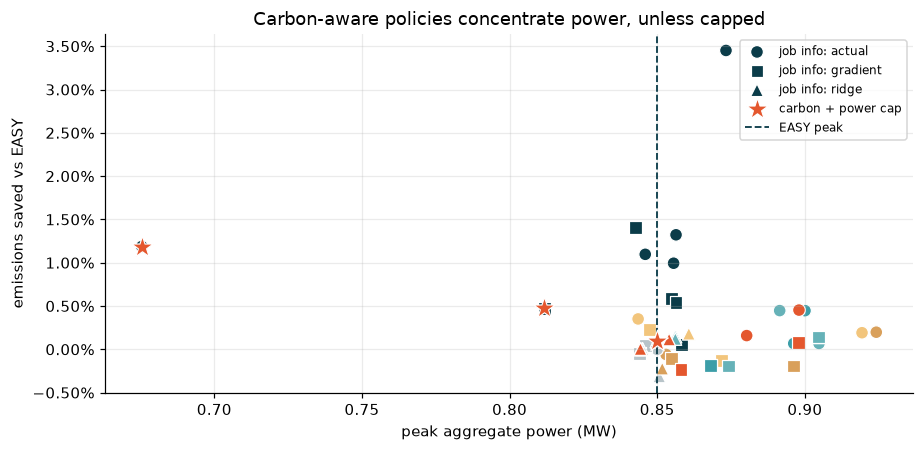

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for job_model, group in carbon.groupby("job_model", observed=True):
    ax.scatter(group.peak_power_mw, group.emissions_saved_vs_easy, marker=markers[job_model],
               s=70, lw=0.8, edgecolor="white",
               color=[SIGNAL_COLORS[s] for s in group.signal], label=f"job info: {job_model}")
capped = matrix[matrix.scheduler_family.eq("power-cap-carbon")]
ax.scatter(capped.peak_power_mw, capped.emissions_saved_vs_easy, marker="*", s=220,
           color=RUST, edgecolor="white", lw=0.8, zorder=5, label="carbon + power cap")
ax.axvline(reference.peak_power_mw, color=INK, lw=1.2, ls="--", label="EASY peak")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(xlabel="peak aggregate power (MW)", ylabel="emissions saved vs EASY",
       title="Carbon-aware policies concentrate power, unless capped")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Most carbon-aware points sit to the **right** of the EASY peak: every job aims
independently at the same clean interval, so the greedy rule manufactures
exactly the concentration the power cap exists to prevent, up to 0.924 MW
against EASY's 0.850. Composing the two policies fixes it - the capped runs
hold 0.675 MW while keeping 90% of the fixed-budget saving (1.19% against
1.32%) - the best trade anywhere in the matrix, and the one worth keeping.

## 7. The delay budget: the one parameter that actually buys carbon

Everything above holds the budget at six hours. This sweep moves it, on the
same cohort, twice: once planning with actual durations and powers, once with
the gradient model's. Nothing else changes, so the gap between the two curves
is the price of imperfect job information.

Unlike every other artifact this notebook reads, the sweep is not written by a
default run of anything, so here is the command that produced it (~6 minutes):

```bash
.venv/bin/python scripts/carbon_tradeoff.py \
  --workload data/processed/pm100_clean.parquet \
  --job-predictions data/job_predictions/test_predictions.parquet \
  --carbon-cache data/carbon_intensity/actual/actual.json \
  --max-delay-hours 0 1 3 6 12 24 --decision-granularity-minutes 15 \
  --output data/simulations/carbon_tradeoff_test_cohort.csv
```

In [21]:
frontier = pd.read_csv(DATA / "simulations" / "carbon_tradeoff_test_cohort.csv")
frontier["effective_ci"] = effective_ci(frontier.total_emissions_tco2e, frontier.total_energy_mwh)
frontier = frontier.sort_values(["inputs", "max_delay_hours"])
frontier.set_index(["inputs", "max_delay_hours"])[[
    "effective_ci", "total_emissions_tco2e", "emissions_saved_vs_easy", "carbon_benefit_retained",
    "waiting_mean_s", "waiting_p95_s", "bounded_slowdown_mean", "bounded_slowdown_p95", "peak_power_mw",
]]

effective_ci  total_emissions_tco2e  \
inputs    max_delay_hours                                        
actual    0.000                 258.740                 17.471   
          1.000                 258.199                 17.435   
          3.000                 256.515                 17.321   
          6.000                 255.319                 17.240   
          12.000                250.455                 16.912   
          24.000                247.373                 16.704   
predicted 0.000                 258.802                 17.475   
          1.000                 258.498                 17.455   
          3.000                 257.613                 17.395   
          6.000                 257.281                 17.373   
          12.000                254.251                 17.168   
          24.000                251.964                 17.014   

                           emissions_saved_vs_easy  carbon_benefit_retained  \
inputs    max_delay_hours                                                     
actual    0.000                              0.000                      NaN   
          1.000                              0.002                      NaN   
          3.000                              0.009                      NaN   
          6.000                              0.013                      NaN   
          12.000                             0.032                      NaN   
          24.000                             0.044                      NaN   
predicted 0.000                             -0.000                      NaN   
          1.000                              0.001                    0.447   
          3.000                              0.004                    0.507   
          6.000                              0.006                    0.426   
          12.000                             0.017                    0.542   
          24.000                             0.026                    0.596   

                           waiting_mean_s  waiting_p95_s  \
inputs    max_delay_hours                                  
actual    0.000                   422.904          0.000   
          1.000                 1,500.717      3,525.000   
          3.000                 5,013.758     10,671.000   
          6.000                 7,870.680     21,237.000   
          12.000               12,140.318     41,435.000   
          24.000               42,542.245     84,883.000   
predicted 0.000                   458.262      1,341.000   
          1.000                 1,524.933      3,540.000   
          3.000                 5,036.908     10,683.000   
          6.000                 7,922.732     21,281.000   
          12.000               12,400.421     41,076.000   
          24.000               43,584.909     85,080.000   

                           bounded_slowdown_mean  bounded_slowdown_p95  \
inputs    max_delay_hours                                                
actual    0.000                            2.111                 1.000   
          1.000                           72.036               320.400   
          3.000                          310.416             1,022.300   
          6.000                          459.978             1,708.900   
          12.000                         656.739             2,340.300   
          24.000                       2,979.301             8,416.200   
predicted 0.000                            3.000                 1.852   
          1.000                           72.718               320.800   
          3.000                          312.263             1,022.600   
          6.000                          463.066             1,714.500   
          12.000                         674.841             2,352.300   
          24.000                       2,991.058             8,416.200   

                           peak_power_mw  
inputs    max_delay_hours                 
actual    0.000                

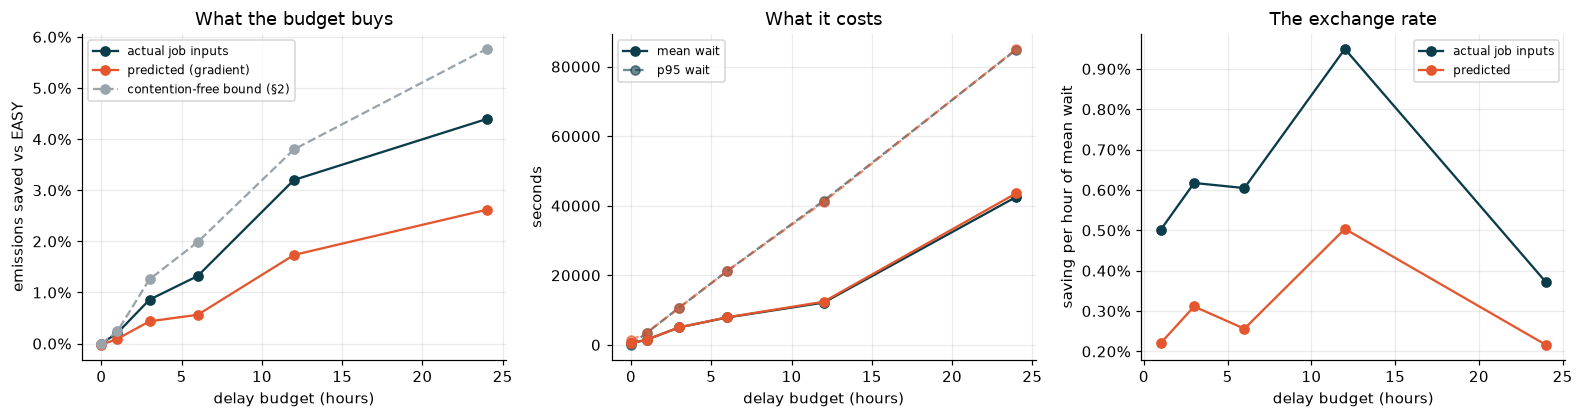

In [22]:
actual_arm = frontier[frontier.inputs.eq("actual")]
predicted_arm = frontier[frontier.inputs.eq("predicted")]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.9))
axes[0].plot(actual_arm.max_delay_hours, actual_arm.emissions_saved_vs_easy, "o-", color=INK, label="actual job inputs")
axes[0].plot(predicted_arm.max_delay_hours, predicted_arm.emissions_saved_vs_easy, "o-", color=RUST, label="predicted (gradient)")
axes[0].plot(bounds.index, bounds["reachable saving"], "o--", color=GREY, label="contention-free bound (§2)")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set(xlabel="delay budget (hours)", ylabel="emissions saved vs EASY", title="What the budget buys")
axes[0].legend(fontsize=8)

axes[1].plot(actual_arm.max_delay_hours, actual_arm.waiting_mean_s, "o-", color=INK, label="mean wait")
axes[1].plot(actual_arm.max_delay_hours, actual_arm.waiting_p95_s, "o--", color=INK, alpha=0.6, label="p95 wait")
axes[1].plot(predicted_arm.max_delay_hours, predicted_arm.waiting_mean_s, "o-", color=RUST)
axes[1].plot(predicted_arm.max_delay_hours, predicted_arm.waiting_p95_s, "o--", color=RUST, alpha=0.6)
axes[1].set(xlabel="delay budget (hours)", ylabel="seconds", title="What it costs")
axes[1].legend(fontsize=8)

rate = actual_arm[actual_arm.max_delay_hours > 0]
axes[2].plot(rate.max_delay_hours, rate.emissions_saved_vs_easy / (rate.waiting_mean_s / 3600), "o-", color=INK,
             label="actual job inputs")
rate = predicted_arm[predicted_arm.max_delay_hours > 0]
axes[2].plot(rate.max_delay_hours, rate.emissions_saved_vs_easy / (rate.waiting_mean_s / 3600), "o-", color=RUST,
             label="predicted")
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[2].set(xlabel="delay budget (hours)", ylabel="saving per hour of mean wait",
            title="The exchange rate")
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

**Carbon falls monotonically with the budget; waiting grows faster than
linearly.** The exchange rate in the third panel is not monotone: it improves
from 0.50%/h at a one-hour budget to 0.95%/h at twelve, then collapses to
0.37%/h at twenty-four, where mean waiting reaches 11.8 hours. Measured against
mean waiting alone, twelve hours is the best buy on this cohort.

That measurement is generous, though, and the tail is the reason: p95 bounded
slowdown goes 1.0 -> 320 -> 1,022 -> 1,709 -> 2,340 -> 8,416 across the same
six budgets. The mean is carried by jobs held a little; the tail is carried by
jobs held the whole budget and then meeting a busy machine. Priced in tail
rather than in mean, the left end of the frontier is still the only defensible
region.

The simulated policy captures **two thirds to seven eighths** of §2's
contention-free bound at every budget, so queueing costs comparatively little -
it is the bound itself, set by the signal and by job duration, that constrains
the result. The predicted arm keeps between two fifths and three fifths of the
perfect-information saving, and keeps *more* of it at wider budgets, because a
wide budget offers more nearly-as-clean slots for a duration error to land in.

## 8. Which prediction costs more?

`experiments.ablation` varies exactly one information source at a time on the
same cohort, and splits what the oracle's saving gave up:

$$\text{carbon forecast share} + \text{job model share} + \text{interaction} = 1 - \text{oracle recovery}$$

In [23]:
ablation = pd.read_csv(DATA / "experiments" / "test_ablation_boosted_ridge.csv")
ablation["effective_ci"] = effective_ci(ablation.total_emissions_tco2e, ablation.total_energy_mwh)
ablation.set_index("configuration")[[
    "job_information", "carbon_information", "effective_ci", "total_emissions_tco2e",
    "emissions_saved_vs_easy", "oracle_recovery", "waiting_mean_s", "bounded_slowdown_p95",
]]

,job_information,carbon_information,effective_ci,total_emissions_tco2e,emissions_saved_vs_easy,oracle_recovery,waiting_mean_s,bounded_slowdown_p95
configuration,,,,,,,,
easy_actual_jobs_none_carbon,actual,none,258.740,17.471,0.000,0.000,422.904,1.000
easy_predicted_jobs_none_carbon,predicted,none,258.802,17.475,-0.000,-0.022,458.262,1.852
carbon_actual_jobs_actual_carbon,actual,actual,255.902,17.280,0.011,1.000,"7,740.895","1,708.900"
carbon_actual_jobs_forecast_carbon,actual,forecast,257.568,17.392,0.005,0.413,"7,635.248","1,776.500"
carbon_predicted_jobs_actual_carbon,predicted,actual,257.395,17.380,0.005,0.474,"7,848.783","1,714.500"
carbon_predicted_jobs_forecast_carbon,predicted,forecast,258.591,17.461,0.001,0.052,"7,743.466","1,778.300"


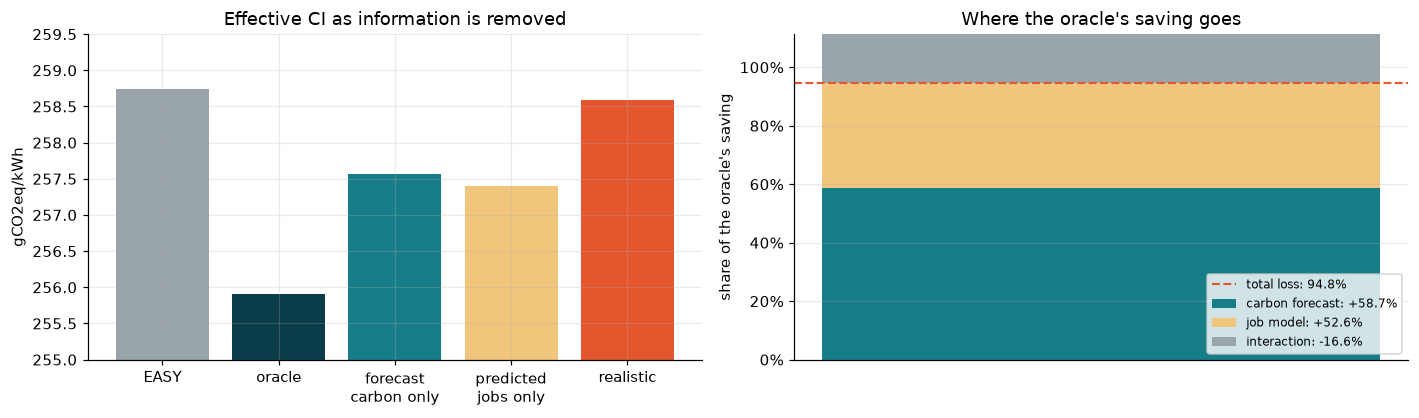

In [24]:
realistic = ablation[ablation.configuration.eq("carbon_predicted_jobs_forecast_carbon")].iloc[0]
shares = pd.Series({
    "carbon forecast": realistic.carbon_forecast_loss_share,
    "job model": realistic.job_model_loss_share,
    "interaction": realistic.interaction_loss_share,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
order = ["easy_actual_jobs_none_carbon", "carbon_actual_jobs_actual_carbon",
         "carbon_actual_jobs_forecast_carbon", "carbon_predicted_jobs_actual_carbon",
         "carbon_predicted_jobs_forecast_carbon"]
rows = ablation.set_index("configuration").reindex(order)
positions = np.arange(len(rows))
axes[0].bar(positions, rows.effective_ci - 255, bottom=255, color=[GREY, INK, TEAL, SAND, RUST])
axes[0].set_xticks(positions, ["EASY", "oracle", "forecast\ncarbon only", "predicted\njobs only", "realistic"])
axes[0].set(ylim=(255, 259.5), ylabel=UNIT, title="Effective CI as information is removed")

bottom = 0.0
for (name, value), color in zip(shares.items(), (TEAL, SAND, GREY)):
    axes[1].bar(0, value, 0.5, bottom=bottom, color=color, label=f"{name}: {value:+.1%}")
    bottom += value
axes[1].axhline(1 - realistic.oracle_recovery, color=RUST, lw=1.4, ls="--",
                label=f"total loss: {1 - realistic.oracle_recovery:.1%}")
axes[1].set_xticks([])
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set(ylabel="share of the oracle's saving", title="Where the oracle's saving goes")
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

The realistic configuration keeps **11.3%** of the oracle's saving on this
cohort. The split is close to even - 59.3% of the loss to the carbon forecast,
52.6% to the job model, and a -23.2% interaction term that says the two errors
partly cancel: a job aimed at the wrong hour by a duration error sometimes
lands where the forecast error would have sent it anyway.

The practical reading is that **neither prediction can be fixed alone.** Halving
the forecast error would recover about six tenths of a saving that is itself
1.1% of emissions. And the shares are specific to this cohort and this budget:
§4 showed the forecast is only ~12% worse here than over the whole test window
inside six hours, so the split describes where this experiment's saving went,
not a general property of the two models.

## 9. What the whole pipeline is worth

One waterfall, in the unit that makes every stage comparable: the effective
carbon intensity of the electricity the schedule bought.

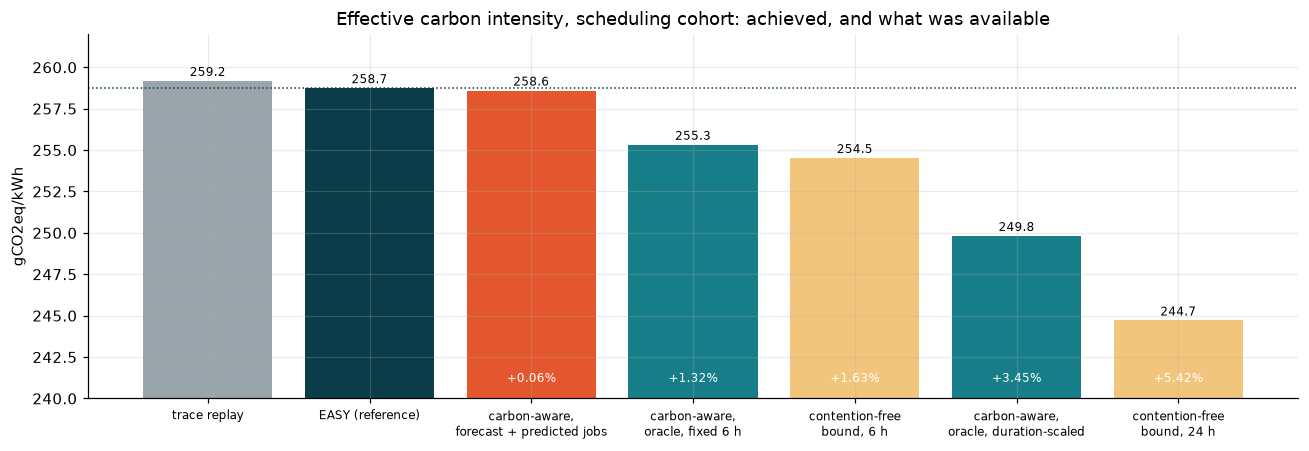

In [25]:
oracle_fixed = matrix[matrix.scheduler.eq("carbon-aware") & matrix.job_model.eq("actual")].iloc[0]
oracle_scaled = matrix[matrix.scheduler.eq("carbon-scaled-delay") & matrix.job_model.eq("actual")].iloc[0]
realistic_row = matrix[
    matrix.scheduler.eq("carbon-aware-forecast-bounded")
    & matrix.job_model.eq("gradient") & matrix.signal.eq("boosted_ridge")
].iloc[0]

stages = pd.Series({
    "trace replay": matrix[matrix.scheduler.eq("trace-replay")].iloc[0].effective_ci,
    "EASY (reference)": reference.effective_ci,
    "carbon-aware,\nforecast + predicted jobs": realistic_row.effective_ci,
    "carbon-aware,\noracle, fixed 6 h": oracle_fixed.effective_ci,
    "contention-free\nbound, 6 h": bounds.loc[6, "contention-free bound"],
    "carbon-aware,\noracle, duration-scaled": oracle_scaled.effective_ci,
    "contention-free\nbound, 24 h": bounds.loc[24, "contention-free bound"],
})

fig, ax = plt.subplots(figsize=(12, 4.2))
colors = [GREY, INK, RUST, TEAL, SAND, TEAL, SAND]
ax.bar(range(len(stages)), stages.values - 240, bottom=240, color=colors)
for index, value in enumerate(stages.values):
    ax.text(index, value + 0.3, f"{value:.1f}", ha="center", fontsize=8)
    if index > 1:
        ax.text(index, 241, f"{1 - value / reference.effective_ci:+.2%}", ha="center", fontsize=8, color="white")
ax.axhline(reference.effective_ci, color=INK, lw=1, ls=":")
ax.set_xticks(range(len(stages)), stages.index, fontsize=8)
ax.set(ylim=(240, 262), ylabel=UNIT,
       title="Effective carbon intensity, scheduling cohort: achieved, and what was available")
fig.tight_layout()
plt.show()